<a href="https://colab.research.google.com/github/maialonso/TP1-TDVI/blob/main/TP1-TDVI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
import seaborn as sns



# Ejercicio 1

## Descripción de

In [150]:
churn = pd.read_csv("churn.csv")
churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [151]:
# RATIO HOMBRES QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
male = churn['gender'] == 'Male'
male_y= churn_y & male
ratio_cantidad_hombres = male_y.sum() / male.sum()

ratio_cantidad_hombres

np.float64(0.2616033755274262)

In [152]:
# RATIO MUJERES QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
female = churn['gender'] == 'Female'
female_y = churn_y & female
ratio_cantidad_mujeres = female_y.sum() / female.sum()

ratio_cantidad_mujeres

np.float64(0.26920871559633025)

In [153]:
# RATIO SENIORS QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
senior = churn['SeniorCitizen'] == 1
senior_y = churn_y & senior
ratio_cantidad_seniors = senior_y.sum() / senior.sum()

ratio_cantidad_seniors

np.float64(0.4168126094570928)

In [154]:
# RATIO PERSONAS CON PAREJA QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
partner = churn['Partner'] == 'Yes'
partner_y = churn_y & partner
ratio_cantidad_partner = partner_y.sum() / partner.sum()

ratio_cantidad_partner

np.float64(0.1966490299823633)

In [155]:
# RATIO PERSONAS CON DEPENDIENTES QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
dependents = churn['Dependents'] == 'Yes'
dependents_y = churn_y & dependents
ratio_cantidad_dependents = dependents_y.sum() / dependents.sum()

ratio_cantidad_dependents

np.float64(0.15450236966824646)

In [156]:
# RATIO PERSONAS CON SERVICIO TELEFONICO QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
phone_service = churn['PhoneService'] == 'Yes'
phone_service_y = churn_y & phone_service
ratio_cantidad_phone_service = phone_service_y.sum() / phone_service.sum()

ratio_cantidad_phone_service

np.float64(0.2670963684955196)

In [157]:
# RATIO PERSONAS CON MULTIPLES LINEAS QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
multiple_lines = churn['MultipleLines'] == 'Yes'
multiple_lines_y = churn_y & multiple_lines
ratio_cantidad_multiple_lines = multiple_lines_y.sum() / multiple_lines.sum()

ratio_cantidad_multiple_lines


np.float64(0.286098956580276)

In [158]:
# RATIO PERSONAS SIN MULTIPLES LINEAS QUE ABANDONAN

no_multiple_lines = churn['MultipleLines'] == 'No'
no_multiple_lines_y = churn_y & no_multiple_lines
ratio_cantidad_no_multiple_lines = no_multiple_lines_y.sum() / no_multiple_lines.sum()

ratio_cantidad_no_multiple_lines

np.float64(0.2504424778761062)

In [159]:
# RATIO PERSONAS CON INTERNET DSL QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
internet_dsl = churn['InternetService'] == 'DSL'
internet_dsl_y = churn_y & internet_dsl
ratio_cantidad_internet_dsl = internet_dsl_y.sum() / internet_dsl.sum()

ratio_cantidad_internet_dsl

np.float64(0.1895910780669145)

In [160]:
# RATIO PERSONAS CON FIBRA OPTICA QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
internet_fiber = churn['InternetService'] == 'Fiber optic'
internet_fiber_y = churn_y & internet_fiber
ratio_cantidad_internet_fiber = internet_fiber_y.sum() / internet_fiber.sum()

ratio_cantidad_internet_fiber

np.float64(0.4189276485788114)

In [161]:
# RATIO PERSONAS SIN SERVICIO DE INTERNET QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
no_internet = churn['InternetService'] == 'No'
no_internet_y = churn_y & no_internet
ratio_cantidad_no_internet = no_internet_y.sum() / no_internet.sum()

ratio_cantidad_no_internet

np.float64(0.07404980340760157)

In [162]:
# RATIO PERSONAS SIN SERVICIO DE INTERNET QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
no_internet = churn['InternetService'] == 'No'
no_internet_y = churn_y & no_internet
ratio_cantidad_no_internet = no_internet_y.sum() / no_internet.sum()

ratio_cantidad_no_internet

np.float64(0.07404980340760157)

In [163]:
# RATIO PERSONAS CON ONLINE BACKUP QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
online_backup = churn['OnlineBackup'] == 'Yes'
online_backup_y = churn_y & online_backup
ratio_cantidad_online_backup = online_backup_y.sum() / online_backup.sum()

ratio_cantidad_online_backup

np.float64(0.21531494442157267)

In [164]:
# RATIO PERSONAS CON DEVICE PROTECTION QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
device_protection = churn['DeviceProtection'] == 'Yes'
device_protection_y = churn_y & device_protection
ratio_cantidad_device_protection = device_protection_y.sum() / device_protection.sum()

ratio_cantidad_device_protection

np.float64(0.2250206440957886)

In [165]:
# RATIO PERSONAS CON TECH SUPPORT QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
tech_support = churn['TechSupport'] == 'Yes'
tech_support_y = churn_y & tech_support
ratio_cantidad_tech_support = tech_support_y.sum() / tech_support.sum()

ratio_cantidad_tech_support

np.float64(0.15166340508806261)

In [166]:
# RATIO PERSONAS CON TECH SUPPORT QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
tech_support = churn['TechSupport'] == 'Yes'
tech_support_y = churn_y & tech_support
ratio_cantidad_tech_support = tech_support_y.sum() / tech_support.sum()

ratio_cantidad_tech_support

np.float64(0.15166340508806261)

In [167]:
# RATIO PERSONAS CON STREAMING MOVIES QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
streaming_movies = churn['StreamingMovies'] == 'Yes'
streaming_movies_y = churn_y & streaming_movies
ratio_cantidad_streaming_movies = streaming_movies_y.sum() / streaming_movies.sum()

ratio_cantidad_streaming_movies

np.float64(0.29941434846266474)

In [168]:
# RATIO PERSONAS CON CONTRATO MES A MES QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
month_to_month = churn['Contract'] == 'Month-to-month'
month_to_month_y = churn_y & month_to_month
ratio_cantidad_month_to_month = month_to_month_y.sum() / month_to_month.sum()

ratio_cantidad_month_to_month

np.float64(0.4270967741935484)

In [169]:
# RATIO PERSONAS CON CONTRATO DE UN AÑO QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
one_year = churn['Contract'] == 'One year'
one_year_y = churn_y & one_year
ratio_cantidad_one_year = one_year_y.sum() / one_year.sum()

ratio_cantidad_one_year

np.float64(0.11269517990495587)

In [170]:
# RATIO PERSONAS CON CONTRATO DE DOS AÑOS QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
two_year = churn['Contract'] == 'Two year'
two_year_y = churn_y & two_year
ratio_cantidad_two_year = two_year_y.sum() / two_year.sum()

ratio_cantidad_two_year

np.float64(0.02831858407079646)

In [171]:
# RATIO PERSONAS CON PAPERLESS BILLING QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
paperless_billing = churn['PaperlessBilling'] == 'Yes'
paperless_billing_y = churn_y & paperless_billing
ratio_cantidad_paperless_billing = paperless_billing_y.sum() / paperless_billing.sum()

ratio_cantidad_paperless_billing

np.float64(0.33565092304003835)

In [172]:
# RATIO PERSONAS CON ELECTRONIC CHECK QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
electronic_check = churn['PaymentMethod'] == 'Electronic check'
electronic_check_y = churn_y & electronic_check
ratio_cantidad_electronic_check = electronic_check_y.sum() / electronic_check.sum()

ratio_cantidad_electronic_check

np.float64(0.4528541226215645)

In [173]:
# RATIO PERSONAS CON MAILED CHECK QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
mailed_check = churn['PaymentMethod'] == 'Mailed check'
mailed_check_y = churn_y & mailed_check
ratio_cantidad_mailed_check = mailed_check_y.sum() / mailed_check.sum()

ratio_cantidad_mailed_check

np.float64(0.19106699751861042)

In [174]:
# RATIO PERSONAS CON BANK TRANSFER AUTOMATIC QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
bank_transfer = churn['PaymentMethod'] == 'Bank transfer (automatic)'
bank_transfer_y = churn_y & bank_transfer
ratio_cantidad_bank_transfer = bank_transfer_y.sum() / bank_transfer.sum()

ratio_cantidad_bank_transfer

np.float64(0.16709844559585493)

In [175]:
# RATIO PERSONAS CON CREDIT CARD AUTOMATIC QUE ABANDONAN

churn_y = (churn['Churn'] == 'Yes')
credit_card = churn['PaymentMethod'] == 'Credit card (automatic)'
credit_card_y = churn_y & credit_card
ratio_cantidad_credit_card = credit_card_y.sum() / credit_card.sum()

ratio_cantidad_credit_card

np.float64(0.15243101182654403)

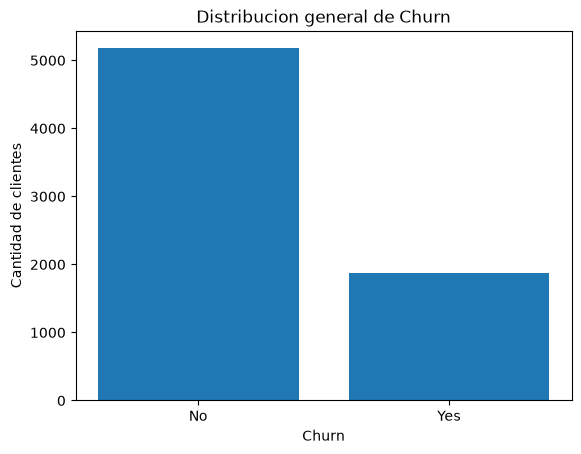

In [176]:
# VISUALIZACION 1: DISTRIBUCION GENERAL DE CHURN

churn_counts = churn['Churn'].value_counts()
plt.bar(churn_counts.index, churn_counts.values)
plt.title('Distribucion general de Churn')
plt.xlabel('Churn')
plt.ylabel('Cantidad de clientes')
plt.show()

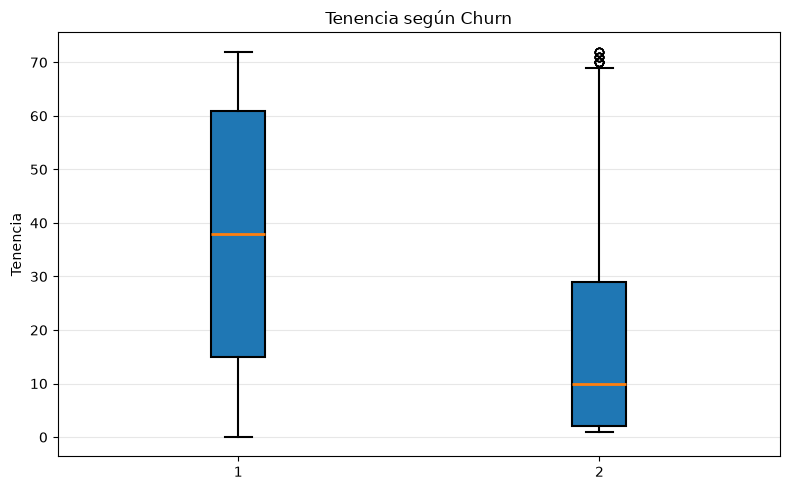

In [177]:
#Grafico boxplot tenencia de los que dejaron vs los que no dejaron

import matplotlib.pyplot as plt

churn_si = churn[churn['Churn'] == 'Yes']['tenure']

churn_no = churn[churn['Churn'] == 'No']['tenure']

plt.figure(figsize=(8, 5))

plt.boxplot(
    [churn_no, churn_si],
    label=['No dejaron', 'Dejaron'],
    patch_artist=True,
    medianprops={'linewidth': 2},
    boxprops={'linewidth': 1.5},
    whiskerprops={'linewidth': 1.5},
    capprops={'linewidth': 1.5}
)

plt.ylabel('Tenencia')
plt.title('Tenencia según Churn')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

Se observa que los clientes que abandonan el servicio tienden a presentar una menor antigüedad que aquellos que permanecen. Esto sugiere una asociación entre la antigüedad del cliente y Churn, por lo que tenure podría aportar información relevante para la predicción del abandono.

Se observa que aproximadamente el 73,5% de los clientes permanece en el servicio, mientras que el 26,5% lo abandona.

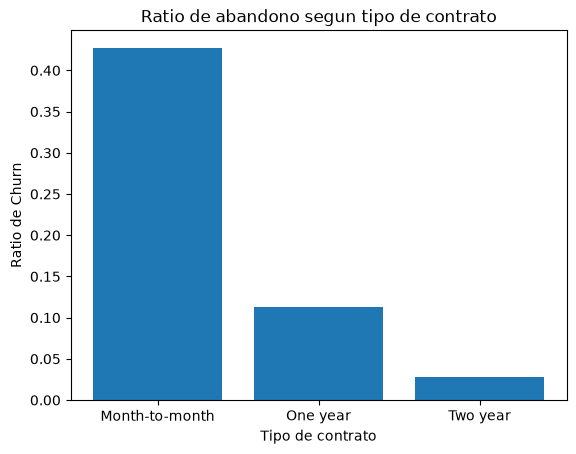

In [178]:
# VISUALIZACION 2: RATIO DE ABANDONO SEGUN TIPO DE CONTRATO

tipos_contrato = ['Month-to-month', 'One year', 'Two year']
ratios_contrato = [
    ratio_cantidad_month_to_month,
    ratio_cantidad_one_year,
    ratio_cantidad_two_year
]
plt.bar(tipos_contrato, ratios_contrato)
plt.title('Ratio de abandono segun tipo de contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Ratio de Churn')
plt.show()

Los clientes que abandonan el servicio tienden a tener menor antigüedad, lo que sugiere que tenure podría ser relevante para predecir Churn.

In [179]:
churn.isna().mean()

customerID          0.000000
gender              0.000000
SeniorCitizen       0.000000
Partner             0.000000
Dependents          0.000000
tenure              0.000000
PhoneService        0.000000
MultipleLines       0.000000
InternetService     0.000000
OnlineSecurity      0.000000
OnlineBackup        0.000000
DeviceProtection    0.000000
TechSupport         0.000000
StreamingTV         0.000000
StreamingMovies     0.000000
Contract            0.000000
PaperlessBilling    0.000000
PaymentMethod       0.000000
MonthlyCharges      0.000000
TotalCharges        0.001562
Churn               0.000000
dtype: float64

Revisamos valores faltantes. Dado que la proporción de valores faltantes es insignificantes, eliminamos esas filas

In [180]:
churn = churn.dropna(subset=["TotalCharges"])
churn.isna().mean()

customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64

Pasamos todas los labels de Yes/No a 1/0

In [181]:

churn['gender'] = churn['gender'].apply(lambda d: 1 if d == 'Male' else 0)
churn['Partner'] = churn['Partner'].apply(lambda d: 1 if d == 'Yes' else 0)
churn['PhoneService'] = churn['PhoneService'].apply(lambda d: 1 if d == 'Yes' else 0)
churn['MultipleLines'] = churn['MultipleLines'].apply(lambda d: 1 if d == 'Yes' else 0)
churn['OnlineSecurity'] = churn['OnlineSecurity'].apply(lambda d: 1 if d == 'Yes' else 0)
churn['OnlineBackup'] = churn['OnlineBackup'].apply(lambda d: 1 if d == 'Yes' else 0)
churn['DeviceProtection'] = churn['DeviceProtection'].apply(lambda d: 1 if d == 'Yes' else 0)
churn['TechSupport'] = churn['TechSupport'].apply(lambda d: 1 if d == 'Yes' else 0)
churn['StreamingTV'] = churn['StreamingTV'].apply(lambda d: 1 if d == 'Yes' else 0)
churn['StreamingMovies'] = churn['StreamingMovies'].apply(lambda d: 1 if d == 'Yes' else 0)
churn['PaperlessBilling'] = churn['PaperlessBilling'].apply(lambda d: 1 if d == 'Yes' else 0)
churn['Churn'] = churn['Churn'].apply(lambda d: 1 if d == 'Yes' else 0)








churn.dtypes

customerID              str
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents              str
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService         str
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract                str
PaperlessBilling      int64
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

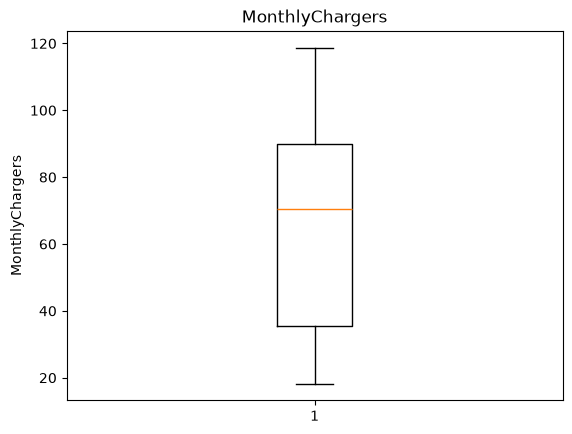

In [182]:
import matplotlib.pyplot as plt

plt.boxplot(churn['MonthlyCharges'])
plt.ylabel('MonthlyChargers')
plt.title('MonthlyChargers')
plt.show()

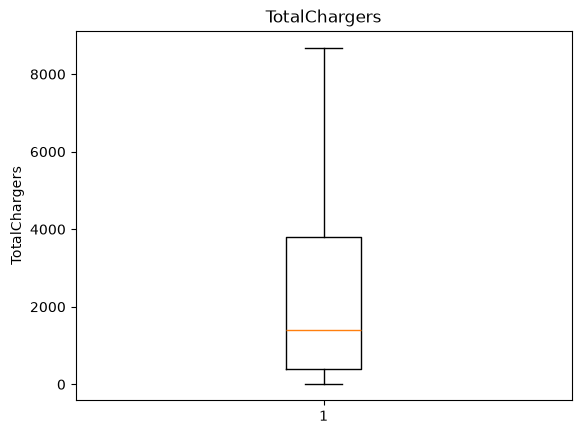

In [183]:
plt.boxplot(churn['TotalCharges'])
plt.ylabel('TotalChargers')
plt.title('TotalChargers')
plt.show()

Escalamos solamente las numericas no binarias con escalador estandar asi no perdemos outliers(aunque no los hay)

REVISAR!

In [184]:

X = churn.drop(columns='Churn')
y = churn['Churn']

variables_numericas = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Train (80%) y test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


Expliquen explıcitamente en una celda de texto en que momento del codigo se debe realizar la division de los datos en entrenamiento y
testeo (Train/Test Split) en relacion con el escalado y la imputacion. Si lo hicieran en el orden incorrecto, ¿que problema conceptual estarıan introduciendo?

Si escalamos las variables previas al entrenamiento, estariamos entrenando al modelo con informacion que normalmente no dispondria, por lo que el modelo seria mas propenso a Data Leakage


In [185]:
def evaluar_knn(X_train, y_train, X_val, y_val, 
                n_neighbors=5, metric='minkowski', p=2, weights='uniform'):

    np.random.seed(42)

    modelo = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        metric=metric,
        p=p,
        weights=weights
    )

    modelo.fit(X_train, y_train)

    pred_train = modelo.predict(X_train)
    pred_val = modelo.predict(X_val)

    resultados = {
        "k": n_neighbors,
        "metric": metric,
        "p": p,
        "weights": weights,
        "acc_train": accuracy_score(y_train, pred_train),
        "acc_val": accuracy_score(y_val, pred_val),
        "bacc_train": balanced_accuracy_score(y_train, pred_train),
        "bacc_val": balanced_accuracy_score(y_val, pred_val)
    }

    return modelo, resultados

In [186]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state = 42) 
resultados = []

#te da indices de filas para entrenar (kf.split) y filas para validar (val_idx)
neighbors=5
#tomo el arreglo en la fila que me da el indice, si era el 0 y 1 en kf_split es X[[0,1]] o sea fila 0 y 1
while neighbors <=115 :
    suma_acum=0
    for train_idx, val_idx in kf.split(X_train, y_train):

        # seleccionamos los datos correspondientes a cada fold
        
        X_train_fold = X_train.iloc[train_idx].copy()
        y_train_fold = y_train.iloc[train_idx]

        X_val_fold = X_train.iloc[val_idx].copy()
        y_val_fold = y_train.iloc[val_idx]


        # escalamos las variables numéricas
        scaler = StandardScaler()
        X_train_fold[variables_numericas] = scaler.fit_transform(
            X_train_fold[variables_numericas]
        )

        # validación usando lo aprendido del train
        X_val_fold[variables_numericas] = scaler.transform(
            X_val_fold[variables_numericas]
        )

        _, res = evaluar_knn(
                X_train_fold[variables_numericas], y_train_fold,
                X_val_fold[variables_numericas], y_val_fold,
                n_neighbors = neighbors
            )
        suma_acum+=res["bacc_val"] 
    resultados.append(suma_acum/5)
    neighbors += 5



print(resultados)

[0.671758970579899, 0.6621595795508839, 0.6845692259104197, 0.6659822491436345, 0.6784673690347971, 0.6712350287884554, 0.6776365123454291, 0.6712985982330124, 0.6754739365277317, 0.6744871929838768, 0.6798505105800611, 0.6757099937645258, 0.6806117243110611, 0.6791407192659956, 0.6805194069011313, 0.6784778964587366, 0.6826471612396446, 0.6785989618340391, 0.6825835917950877, 0.6815106043551142, 0.6857434385805793, 0.6835460412836978, 0.6897219950278168]


In [187]:

scaler = StandardScaler()
X_train_final = X_train[variables_numericas].copy()
X_test_final = X_test[variables_numericas].copy()

X_train_final = scaler.fit_transform(X_train_final) 
X_test_final = scaler.transform(X_test_final)

modelo = KNeighborsClassifier(n_neighbors = 115) 
modelo.fit(X_train_final, y_train) #entrena con los resultados sabidos
y_pred = modelo.predict(X_test_final)




4

In [188]:
#Matriz de confusion
y_real = np.array(churn['Churn'])
y_pred = np.array(y_pred)


# matriz_confunsion = np.array([
#     [np.sum((y_real == 1) & (y_pred == 1)), np.sum((y_real == 0) & (y_pred == 1))],
#     [np.sum((y_real == 0) & (y_pred == 0)), np.sum((y_real == 1) & (y_pred == 0))]
# ])


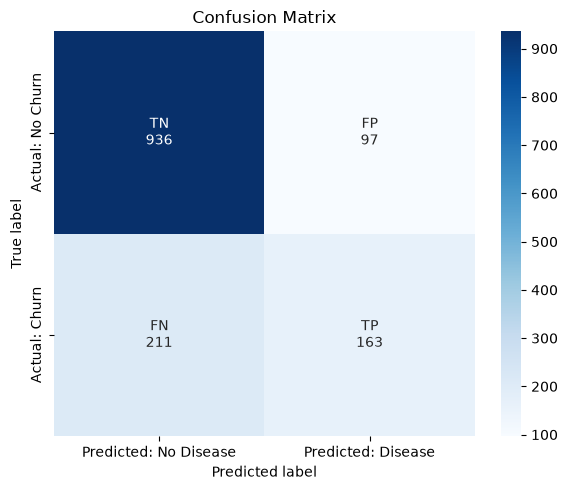

In [189]:
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

labels = [
    f"TN\n{TN}",
    f"FP\n{FP}",
    f"FN\n{FN}",
    f"TP\n{TP}"
]

labels = np.array(labels).reshape(2,2)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    xticklabels=["Predicted: No Disease", "Predicted: Disease"],
    yticklabels=["Actual: No Churn", "Actual: Churn"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.tight_layout()
plt.show()

In [190]:
#Accuracy
accuracy= balanced_accuracy_score(y_test, y_pred)
accuracy

0.6709638092674366

In [191]:
#Precision

precision = precision_score(y_test, y_pred) 
precision

0.6269230769230769

In [192]:
#Recall
recall = recall_score(y_test, y_pred)
recall

0.4358288770053476

In [193]:
#F1_Score
f1 = f1_score(y_test, y_pred)
f1

0.5141955835962145

In [194]:
dejan= (churn["Churn"] == 1).sum()
dejan

np.int64(1869)

In [195]:
nodejan= (churn["Churn"] == 0).sum()
nodejan

np.int64(5163)

In [196]:
#Vemos que hay un desbalanceo fuerte entre los casos que se estan por fugar y los que no
#Por ello, utilizamos la tecnica de Oversampling ADASYN

from imblearn.over_sampling import ADASYN

adasyn = ADASYN()

X_train_balanceado, y_train_balanceado = adasyn.fit_resample(X_train_final, y_train)





In [197]:
#Modelo nuevo
modeloNuevo = KNeighborsClassifier(n_neighbors = 115) 
modeloNuevo.fit(X_train_balanceado, y_train_balanceado) #entrena con los resultados sabidos
y_predBalanceado = modeloNuevo.predict(X_test_final)


In [198]:
#Accuracy
accuracyBalanceado= balanced_accuracy_score(y_test, y_predBalanceado)
accuracyBalanceado

0.7390136200568409

In [199]:
#Precision

precisionBalanceado = precision_score(y_test, y_predBalanceado) 
precisionBalanceado

0.4546762589928058

In [200]:
#Recall
recallBalanceado = recall_score(y_test, y_predBalanceado)
recallBalanceado

0.8449197860962567

In [201]:
#F1_Score
f1Balanceado = f1_score(y_test, y_predBalanceado)
f1Balanceado

0.5912067352666043

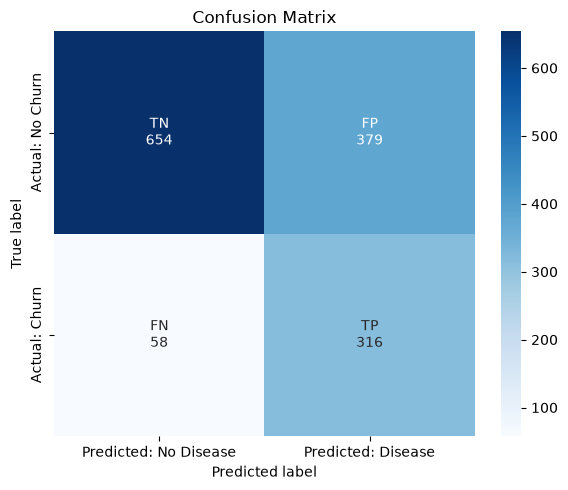

In [202]:
cmBalanceado = confusion_matrix(y_test, y_predBalanceado)
TN, FP, FN, TP = cmBalanceado.ravel()

labels = [
    f"TN\n{TN}",
    f"FP\n{FP}",
    f"FN\n{FN}",
    f"TP\n{TP}"
]

labels = np.array(labels).reshape(2,2)

plt.figure(figsize=(6,5))

sns.heatmap(
    cmBalanceado,
    annot=labels,
    fmt="",
    cmap="Blues",
    xticklabels=["Predicted: No Disease", "Predicted: Disease"],
    yticklabels=["Actual: No Churn", "Actual: Churn"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.tight_layout()
plt.show()

¿Que impacto economico tiene para la empresa un Falso Positivo?
Por cada falso positivo, la empresa estaria otorgando un descuento muy grande a clientes que realmente no se estaban por fugar.

¿Que impacto tiene un Falso Negativo?
Por cada falso negativo, la empresa no estaria otorgando el descuento a cleintes que se estan por fugar, lo que implicaria perder a ese cliente.

Si el descuento ofrecido es muy costoso para la empresa, ¿que metrica (Precision o Recall) intentarıan maximizar y por que? ¿Y si el descuento fuera casi gratuito?
Justifiquen basandose en sus matrices de confusion.
Dado que en la matriz de confusion hay una mayor cantidad de FP, priorizariamos maximizar Precision, dado que en su calculo tiene en cuenta los FP(castiga por mas falsos positivos)



PARTE II
Elegimos como variable objetivo el MonthlyCharges. Y la adaptamos a binaria eligiendo el corte en base a la mediana del dataset: Si es mayor o igual a la mediana: 1, sino 0.

Elegimos este corte para que los datos queden balanceados.

In [203]:
corte = (churn["MonthlyCharges"]).median()
corte

np.float64(70.35)

In [204]:
#Adaptacion binaria
MC= churn.copy()
MC["MonthlyCharges"]= MC['MonthlyCharges'].apply(lambda d: 1 if d >= corte else 0)
MC["MonthlyCharges"]

0       0
1       0
2       0
3       0
4       1
       ..
7038    1
7039    1
7040    0
7041    1
7042    1
Name: MonthlyCharges, Length: 7032, dtype: int64

In [205]:
#Nuevo Modelo
X_MC = MC.drop(columns='MonthlyCharges')
y_MC = MC['MonthlyCharges']

variables_numericas_MC = ['tenure', 'TotalCharges']

# Train (80%) y test (20%)
X_train_MC, X_test_MC, y_train_MC, y_test_MC = train_test_split(
    X_MC, y_MC, test_size=0.2, random_state=42, stratify=y_MC)

In [206]:
from sklearn.linear_model import LogisticRegression

X_train_MC_final = X_train_MC[variables_numericas_MC].copy()
X_test_MC_final = X_test_MC[variables_numericas_MC].copy()

X_train_MC_final = scaler.fit_transform(X_train_MC_final) 
X_test_MC_final = scaler.transform(X_test_MC_final)

modelo_MC = LogisticRegression(max_iter= 1000, random_state= 42) 
modelo_MC.fit(X_train_MC_final, y_train_MC) #entrena con los resultados sabidos
y_pred_MC = modelo_MC.predict(X_test_MC_final)


In [207]:
#Accuracy
accuracy_MC= balanced_accuracy_score(y_test_MC, y_pred_MC)
accuracy_MC

0.9346911559677518

In [208]:
#Precision

precision_MC = precision_score(y_test_MC, y_pred_MC) 
precision_MC

0.9693721286370597

In [209]:
#Recall
recall_MC = recall_score(y_test_MC, y_pred_MC)
recall_MC

0.8978723404255319

In [210]:
#F1_Score
f1_MC = f1_score(y_test_MC, y_pred_MC)
f1_MC

0.9322533136966127